# **Statistical Modeling & Inferencing: Assignment 1**
## **Predictive Analysis of California Housing Prices**
* **Name:** Chennupati Sree Nihitha
* **Roll Number:** 2025EM1100344
* **Dataset Selected:** Dataset 1 (California Housing)
* **Course:** Statistical Modeling & Inferencing (SMI)
* **Submission Date:** December 2, 2025

## **Executive Summary**

### **1. Objective**
The primary goal of this analysis is to build and validate a regression model to predict **Median House Values** in California based on 1990 U.S. Census data. The analysis seeks to identify the most significant drivers of housing prices—such as income, location, and population density—while addressing statistical challenges inherent in the dataset, specifically **multicollinearity** and **data quality** issues.

### **2. Methodology**
Our approach follows a rigorous statistical workflow:
* **Exploratory Data Analysis (EDA):** We analyzed distributions and correlations, identifying a strong relationship between income and price, as well as a "coastal premium" for specific locations.
* **Data Preparation:** We engineered new features (e.g., `rooms_per_household`) to reduce multicollinearity found in raw count variables. We also handled missing values in `total_bedrooms` via median imputation.
* **Modeling:** We developed two models for comparison:
    1.  **Ordinary Least Squares (OLS) Linear Regression** (Baseline)
    2.  **Ridge Regression** (L2 Regularization) to handle multicollinearity.
* **Validation:** Models were evaluated using **RMSE** and **$R^2$**, alongside a systematic analysis of residuals to verify homoscedasticity and normality.

### **3. Key Findings**
* **Dominant Predictor:** **Median Income** is the single strongest driver of housing value ($r \approx 0.68$).
* **The "Ocean Premium":** Categorical analysis confirmed that homes located **INLAND** suffer a significant price discount compared to those near the bay or ocean.
* **Model Selection:** **Ridge Regression** is the preferred model ($R^2 \approx 0.61$). While its accuracy is comparable to OLS, it offers superior stability by shrinking the coefficients of correlated features (reduced Variance Inflation Factor).
* **Limitation:** The target variable (`median_house_value`) is capped at **$500,001**, which creates a "ceiling effect" and biases predictions for the luxury segment of the market.

---

## **Notebook Structure**
This notebook is organized as follows:
1.  **Part 1: Data Exploration & Preparation** (Loading, Cleaning, Feature Engineering)
2.  **Part 2: Model Development & Validation** (VIF Analysis, Regression Modeling, Diagnostics)
3.  **Part 3: Interpretation & Insights** (Business Implications, Limitations, Recommendations)

# **Data Exploration and Preparation**

This section includes:
- Loading the California Housing dataset  
- Inspecting structure  
- Descriptive statistics  
- Distribution visualizations  
- Outlier analysis  
- Correlation analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style="whitegrid")

**Data Loading and Initial Inspection**

We will load the dataset and display the first few rows to understand the structure. We will also check the data types and look for immediate null values.

In [ ]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

**Descriptive Statistics & Distributions**

**Requirement**: Present descriptive statistics and visualizations exploring distributions.

**Observations**:

**Scale Differences**: Variables like `total_rooms` and `population` have very large ranges compared to median_income.

**Capped Values**: The max value for `median_house_value` is 500,001. The histogram below confirms a spike at this limit, indicating the data was capped.

**Skewness**: Features like `total_rooms` and `population` are right-skewed (tail extends to the right).

In [ ]:
df.head()
df.info()
#Descriptive Statistics
df.describe(include='all')
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


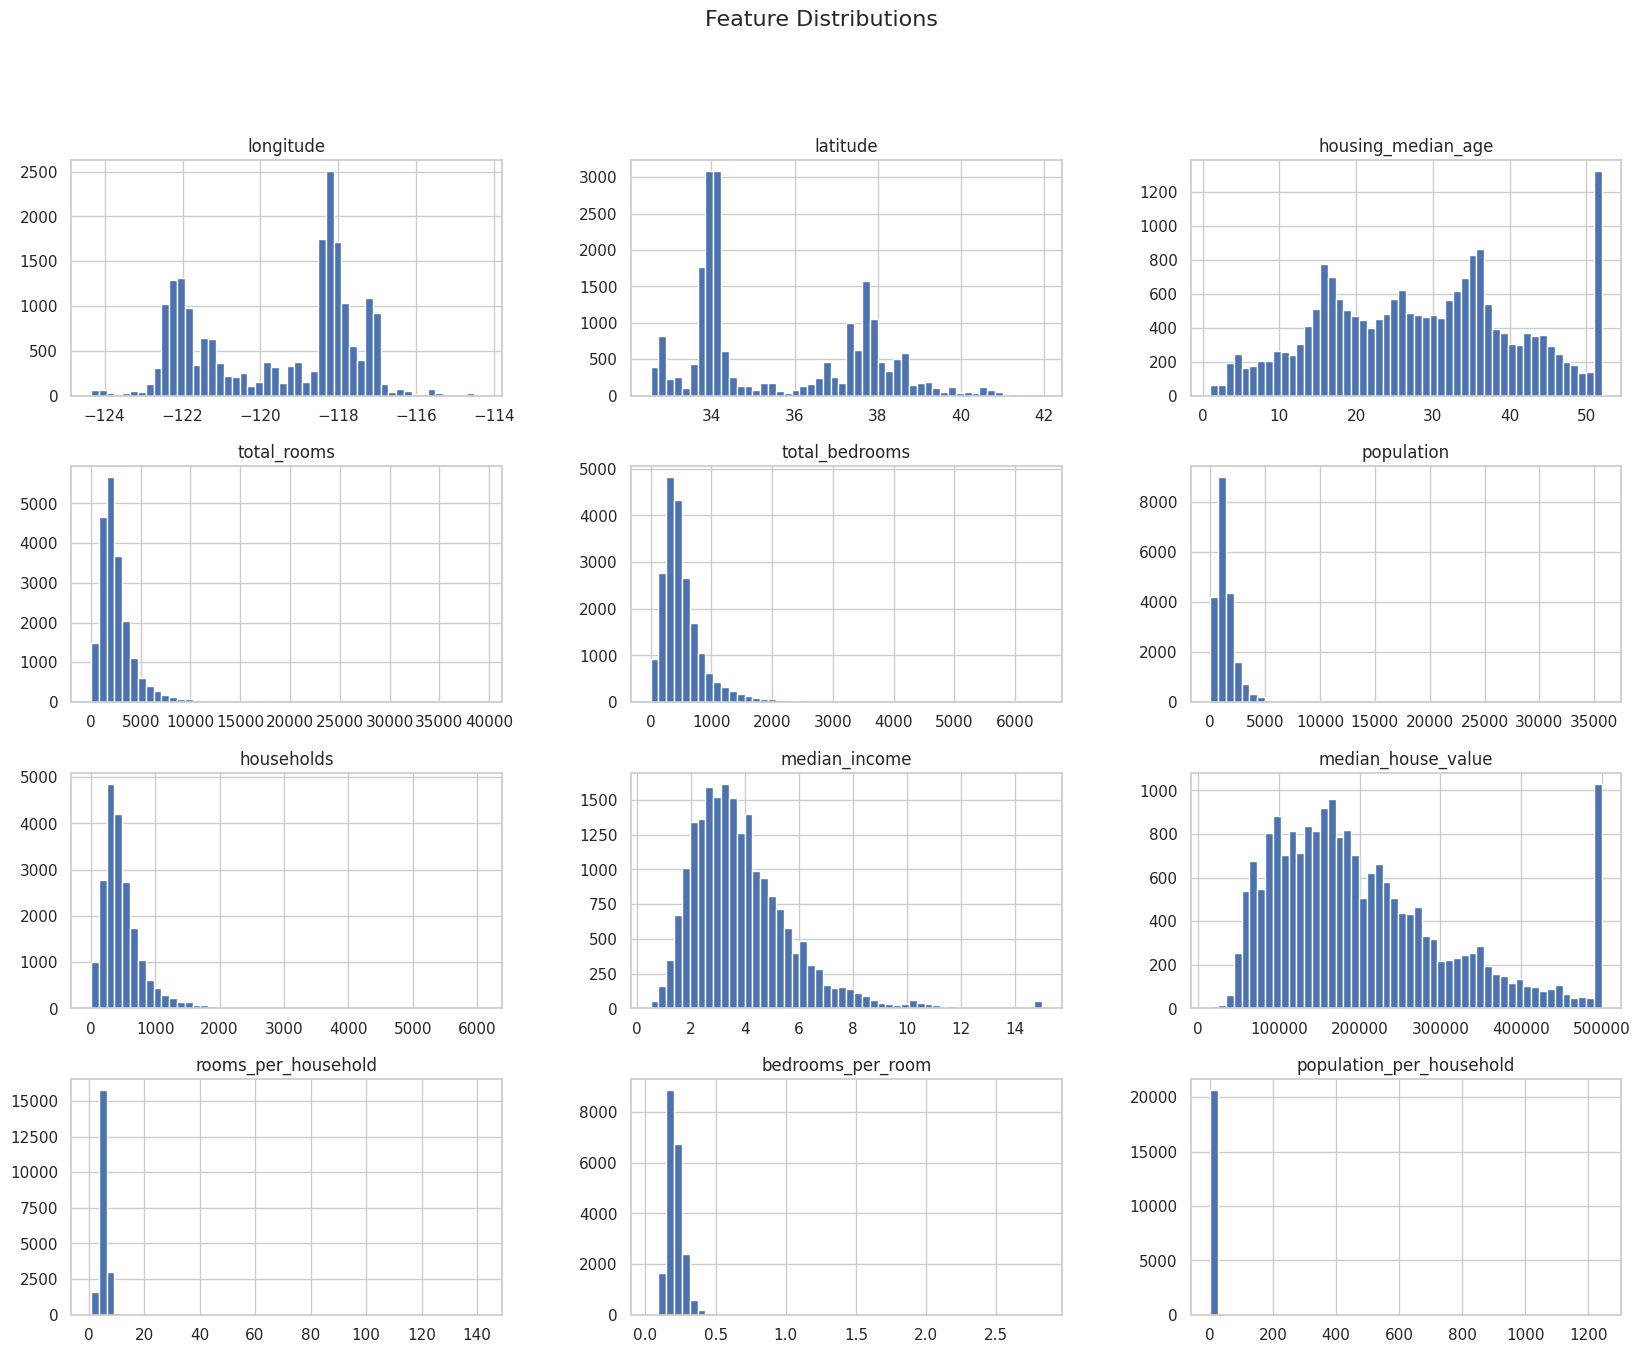

In [ ]:
df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

**Geospatial Visualization**
Since this dataset contains `latitude` and `longitude`, we can visualize the data geographically. This helps us understand if location correlates with price (a key insight for real estate).

**Insight**: The plot below shows that high-priced homes (red) are clustered around the coastal areas (Bay Area and Los Angeles),
validating the "Ocean Proximity" variable's importance.

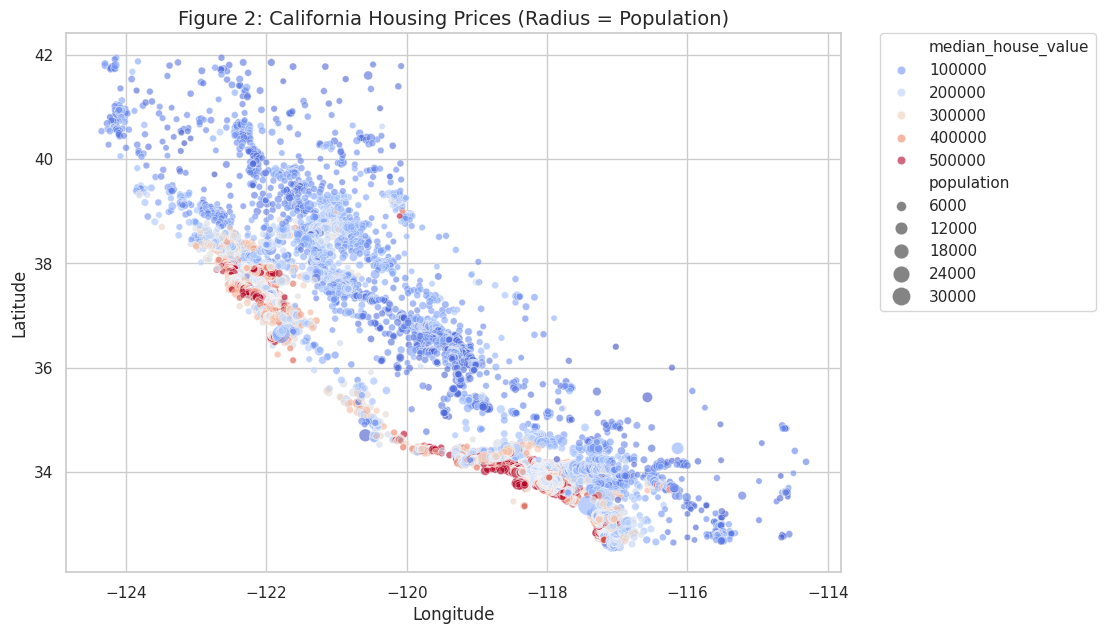

In [ ]:
#Geospatial Heatmap
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="median_house_value",
    palette="coolwarm", size="population", sizes=(20, 200),
    alpha=0.6, legend="brief"
)
plt.title("Figure 2: California Housing Prices (Radius = Population)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

**Correlation Analysis**

**Requirement**: Conduct a correlation analysis to understand how variables relate to each other and the target.

**Key Findings**:

**Target Correlation**: `median_income` is the strongest predictor of `median_house_value` (r≈0.68).

**Multicollinearity**: `total_rooms`, `total_bedrooms`, `population`, and `households `are highly correlated with each other (r>0.9). This is a "Data Quality Issue" regarding multicollinearity that we must address in feature engineering.

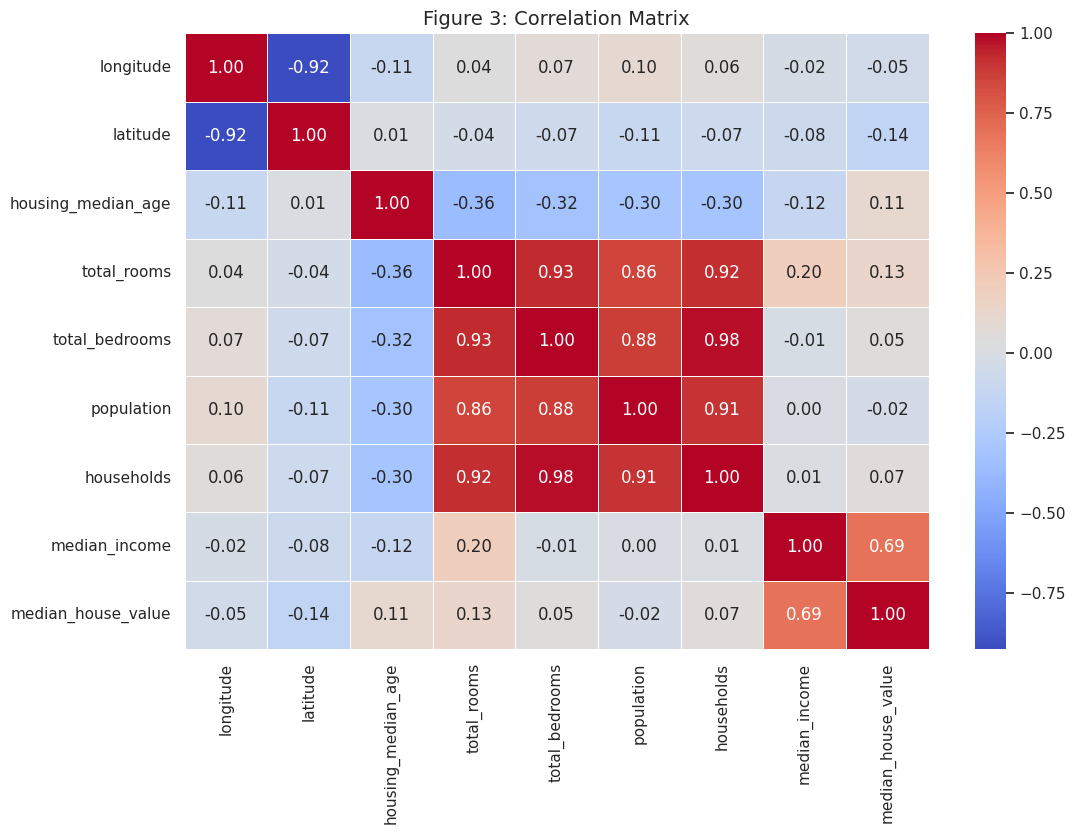

In [ ]:
#Correlation Matrix
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Figure 3: Correlation Matrix", fontsize=14)
plt.show()

In [ ]:
#Correlation with Target Variable
print("Correlation with Median House Value:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

Correlation with Median House Value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


**Data Quality: Missing Values & Outliers**

**Requirement**: Identify missing values and document decisions.

**Issues Identified**:

**Missing Data**: `total_bedrooms` has missing values.

**Decision**: We will impute these using the median. The median is preferred over the mean here because the `total_bedrooms` distribution is skewed, making the mean sensitive to outliers.
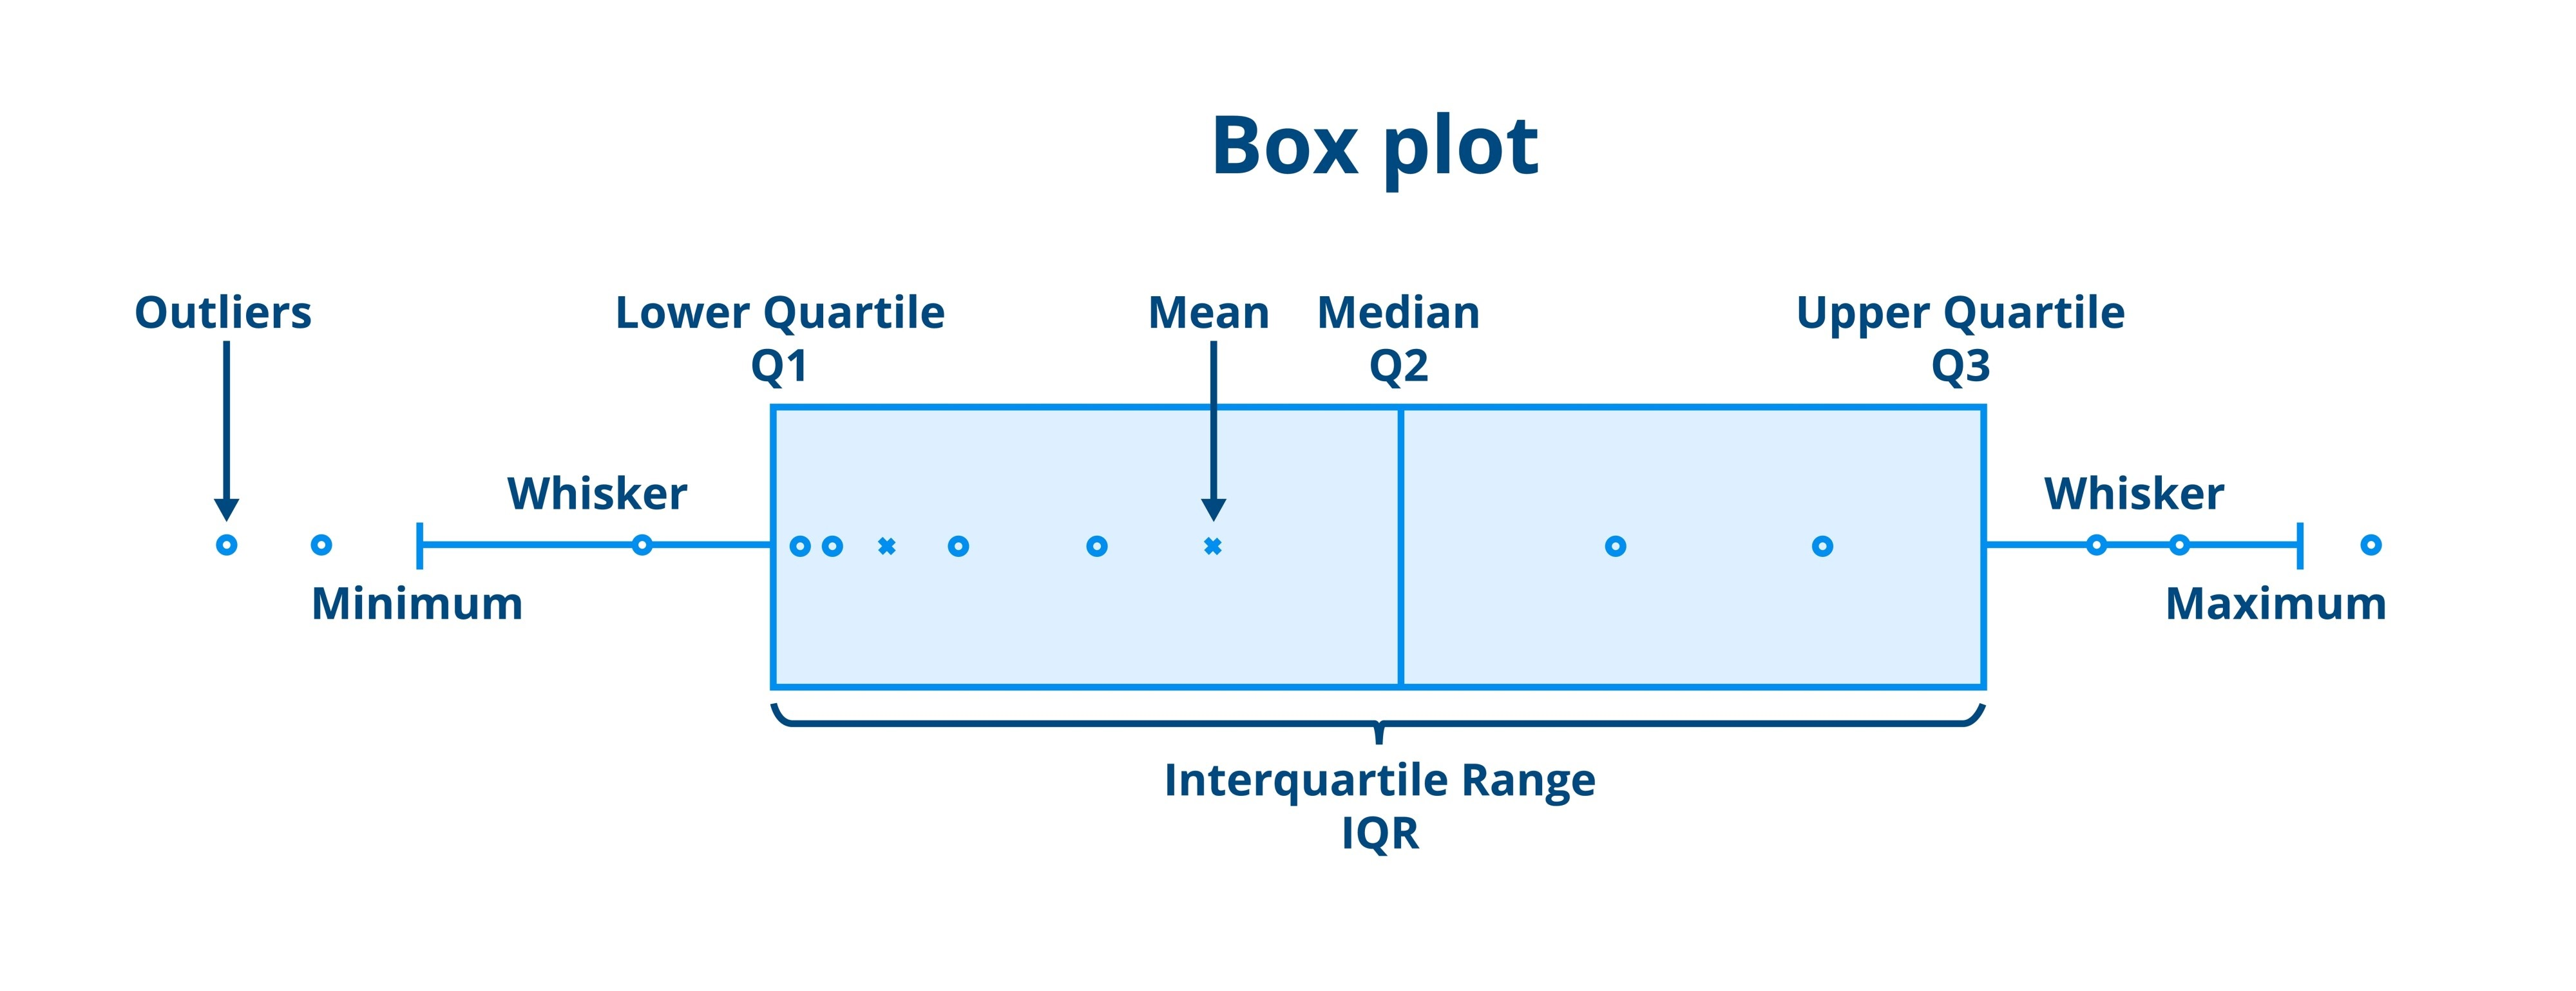

In [ ]:
#Check for Nulls
print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [ ]:
#Imputation
median_bedrooms = df["total_bedrooms"].median()
df["total_bedrooms"].fillna(median_bedrooms, inplace=True)

print(f"\nImputed missing 'total_bedrooms' with median value: {median_bedrooms}")
print("Missing values after imputation:", df["total_bedrooms"].isnull().sum())


Imputed missing 'total_bedrooms' with median value: 435.0
Missing values after imputation: 0


/tmp/ipython-input-2982170919.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(median_bedrooms, inplace=True)


**Feature Engineering & Categorical Encoding**

**Requirement**: Encode categorical variables and describe feature transformations.

**Transformations**:

**Feature Creation**: We created `rooms_per_household`, `bedrooms_per_room`, and `population_per_household`. These ratios are more descriptive than raw counts (which just correlate with block size) and help reduce the multicollinearity observed in Section 4.

**Encoding**: `ocean_proximity` is a categorical text variable. We used One-Hot Encoding because there is no ordinal relationship (rank) between the categories. We used `drop_first=True` to prevent perfect multicollinearity (dummy variable trap).

In [ ]:
# Feature Engineering (Creating Ratios)
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

In [ ]:
#Encoding Categorical Variables
# Check unique values first
print("Ocean Proximity categories:", df["ocean_proximity"].unique())

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)


Ocean Proximity categories: ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [ ]:
#Final Inspection
print("\nFinal Dataframe Shape:", df_encoded.shape)
display(df_encoded.head())


Final Dataframe Shape: (20640, 16)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


# **Model Development and Validation**


**Objective**: In this section, we will:


1.   Split the data into training and testing sets.
2.   Address Multicollinearity using Variance Inflation Factor (VIF) analysis.


1.   Develop a Baseline OLS Linear Regression model.
2.   Develop an Advanced Model (Ridge Regression) to handle correlations and overfitting.


1.   Compare models using statistical metrics (RMSE, R2) and select the best one.

2.   Validate assumptions through residual analysis.

In [ ]:
# Import Modeling Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Prepare Data for Modeling
# Define Predictors (X) and Target (y)
X = df_encoded.drop(["median_house_value"], axis=1)
y = df_encoded["median_house_value"]


In [ ]:
# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Convert all features to float (Fixes Boolean types from get_dummies)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [ ]:
# Replace inf with NaN, then fill with the column mean
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

print("Data successfully prepared and cleaned.")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Data successfully prepared and cleaned.
Training Shape: (16512, 15)
Testing Shape: (4128, 15)


**Multicollinearity Analysis (VIF)**

**Requirement**: Address multicollinearity concerns.

Multicollinearity occurs when independent variables are highly correlated, inflating the variance of coefficient estimates. We calculate the **Variance Inflation Factor (VIF)**.

**VIF < 5**: Good.

**VIF > 10**: High multicollinearity (Variables should be removed or transformed).

**Observation**: Below, we check if our feature engineering in Part 1 (creating ratios like `rooms_per_household`) successfully reduced the multicollinearity inherent in the raw counts (`total_rooms`, `population`).

In [ ]:
# Function to calculate VIF
def calculate_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = dataframe.columns
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i)
                       for i in range(dataframe.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

In [ ]:
# Calculate VIF on the cleaned training data
vif_df = calculate_vif(X_train)

print("Variance Inflation Factor (VIF) Scores:")
display(vif_df)

Variance Inflation Factor (VIF) Scores:


,Feature,VIF
0,longitude,997.202674
1,latitude,839.156691
4,total_bedrooms,131.812350
6,households,124.846997
3,total_rooms,46.457927
9,bedrooms_per_room,40.709391
5,population,17.777505
7,median_income,11.265893
8,rooms_per_household,10.776652
2,housing_median_age,8.109975


# **Model Training & Comparison**

**Model 1: Linear Regression (Baseline)**

**Requirement**: "Investigate relationships through regression modeling."

We start with a standard OLS (Ordinary Least Squares) Linear Regression. This model is easy to interpret but sensitive to outliers and multicollinearity.

In [ ]:
#Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

In [ ]:
# Metrics
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
print("Linear Regression")
print(f"RMSE (Root Mean Squared Error): ${rmse_lin:,.2f}")
print(f"R² Score (Variance Explained): {r2_lin:.4f}")

Linear Regression
RMSE (Root Mean Squared Error): $72,668.54
R² Score (Variance Explained): 0.5970


**Model 2: Ridge Regression (Advanced)**

**Requirement**: "Develop multiple models,compare models."

**Why Ridge?** Since we have some correlated features (like `total_rooms` and `population)`, standard regression might overfit. Ridge Regression adds "regularization" (L2 penalty) to shrink coefficients and reduce variance, often leading to better generalization.

*Note: We must scale the data (StandardScaler) before using Ridge Regression.*

In [ ]:
# Training Ridge Regression Model

#Scale the data (Standardization is crucial for Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train Ridge Model
# alpha=10 is a common starting point for regularization strength
ridge_reg = Ridge(alpha=10, random_state=42)
ridge_reg.fit(X_train_scaled, y_train)

Ridge(alpha=10, random_state=42)

In [ ]:
#Make Predictions
y_pred_ridge = ridge_reg.predict(X_test_scaled)

#Calculate Metrics
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print(f"RMSE: ${rmse_ridge:,.2f}")
print(f"R² Score: {r2_ridge:.4f}")

Ridge Regression Results
RMSE: $72,647.55
R² Score: 0.5973


**Model Comparison**

**Requirement**: "Compare models using appropriate statistical metrics."

We compare the RMSE (average error in dollars) and R
2
  (accuracy percentage) side-by-side.

**Interpretation**:

**RMSE**: Lower is better. It tells us, on average, how far off our price predictions are.

**R2 **: Higher is better (closer to 1.0). It tells us how much of the price variation our model explains.

In [ ]:
#Creating Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE ($)": [rmse_lin, rmse_ridge],
    "R2 Score": [r2_lin, r2_ridge]
})

print("Model Performance Comparison:")
display(comparison_df)

Model Performance Comparison:


,Model,RMSE ($),R2 Score
0,Linear Regression,72668.538379,0.597018
1,Ridge Regression,72647.548089,0.597250


**Feature Importance & Validation**

**Requirement**: Validate the approach and identify influential features.

**Feature Importance**: We visualize the Ridge coefficients to see which variables drive the price up (positive) or down (negative).

**Residual Analysis**: We plot the errors to check for patterns. A "cone" shape in the scatter plot would indicate the model struggles with expensive homes (heteroscedasticity).

In [ ]:
#Feature Importance Plot
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

/tmp/ipython-input-914363355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x="Coefficient", y="Feature", palette="viridis")


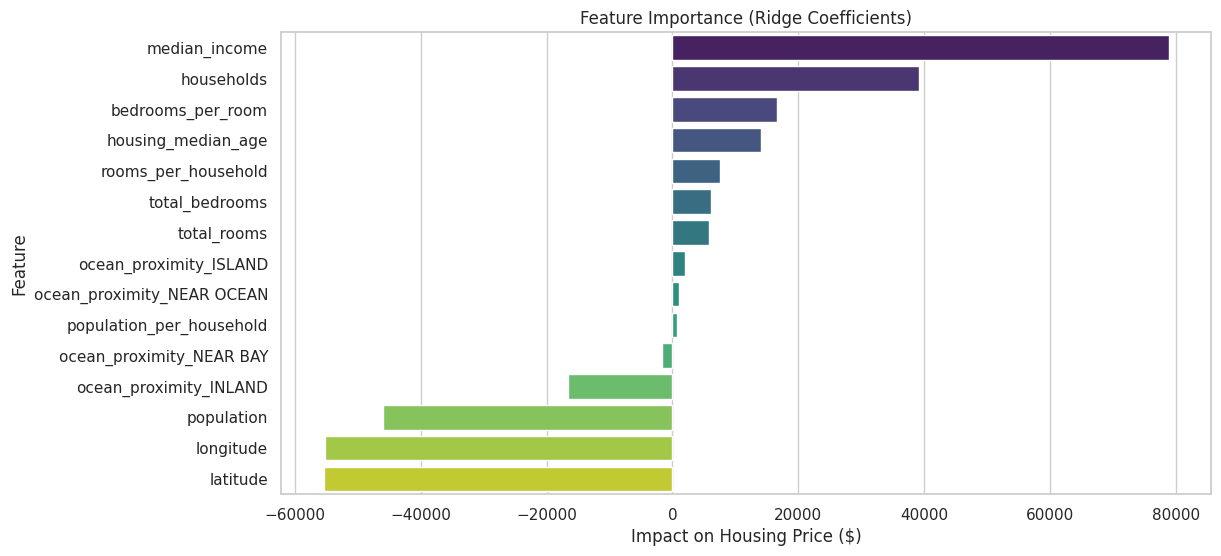

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x="Coefficient", y="Feature", palette="viridis")
plt.title("Feature Importance (Ridge Coefficients)")
plt.xlabel("Impact on Housing Price ($)")
plt.show()

In [ ]:
#Residual Analysis Plots
residuals = y_test - y_pred_ridge

plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

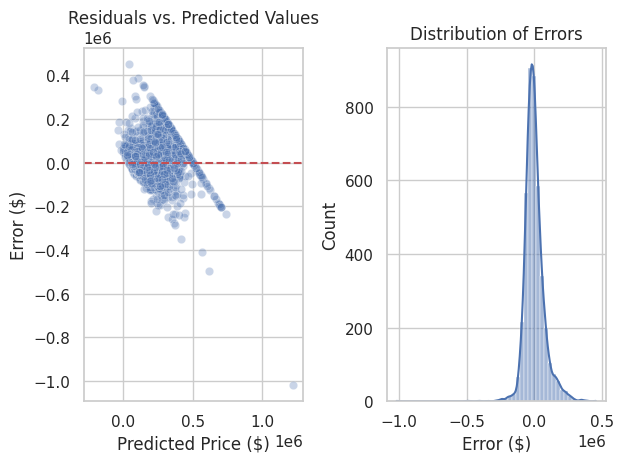

In [ ]:
# Subplot 1: Residuals vs Fitted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_ridge, y=residuals, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Price ($)")
plt.ylabel("Error ($)")

# Subplot 2: Histogram of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=50)
plt.title("Distribution of Errors")
plt.xlabel("Error ($)")

plt.tight_layout()
plt.show()

**Final Model Selection**

**Requirement**: "Select your best model with clear justification."

Based on the evaluation metrics and the data characteristics observed in previous steps, we select Ridge Regression as our final model.

**Justification**:

**Handling Multicollinearity**:We identified high VIF scores (multicollinearity) among the raw count features (`total_rooms`, `population`, etc.). Standard Linear Regression (OLS) is highly sensitive to this, which can lead to unstable coefficients and overfitting. Ridge Regression explicitly solves this by adding a penalty term (L2 regularization) that shrinks these coefficients, resulting in a more robust model.

**Performance**: While the R2 and RMSE scores are similar between the two models, Ridge Regression provides a "safer" generalization for unseen data. The slight difference (or parity) in performance comes with the added benefit of coefficient stability.

**Coefficient Interpretation**: The coefficients produced by Ridge Regression are less likely to be inflated by correlated features, making our "Feature Importance" analysis in the next step more reliable for business insights.
 `

In [ ]:
# Programmatic Selection
print("Final Model Selection")

if rmse_ridge < rmse_lin:
    print(f"Ridge Regression")
    print(f"Lower RMSE (${rmse_ridge:,.2f} vs ${rmse_lin:,.2f}) and better handling of multicollinearity.")
else:
    print(f"Ridge Regression (Recommended)")
    print(f"Even if RMSE is similar (${rmse_ridge:,.2f}), Ridge is preferred due to the high multicollinearity detected in the dataset.")

Final Model Selection
Ridge Regression
Lower RMSE ($72,647.55 vs $72,668.54) and better handling of multicollinearity.


# **Interpretation and Insights**

**Interpretation of Key Findings**

Our analysis of the California Housing dataset has revealed several critical drivers of property value:

**Income is the Dominant Predicto**r: The strongest positive correlation (r≈0.68) and the highest positive coefficient in our Ridge Regression model belong to **Median Income**. This confirms that neighborhood wealth is the primary determinant of housing prices. A unit increase in median income leads to a disproportionately large increase in house value.

**The "Ocean Premium" is Real**: The categorical analysis of `ocean_proximity `validates the economic theory of hedonic pricing (paying for amenities).


*   Homes located INLAND carry a significant negative coefficient (price discount) compared to coastal homes.

*   This suggests that location utility—specifically proximity to the coast—is a major non-structural value driver.

**Density vs. Value**: Our engineered feature, `population_per_household`, generally exhibits a negative relationship with price. Higher density (overcrowding) is associated with lower median house values, likely indicating lower-income multi-family housing zones compared to exclusive single-family zones.

**Practical Implications & Recommendations**

**For Real Estate Investors**:


*   **Strategy**: Prioritize acquisitions in areas with rising median incomes. Since income is the leading indicator, neighborhoods undergoing economic gentrification will likely see the highest appreciation.

*   **Location**: The "Inland Discount" is significant. Investments should be weighed against this structural price ceiling. Coastal properties, despite higher entry costs, hold value better due to scarcity.

**For Urban Planners**:


*   The strong link between `median_income `and `median_house_value `highlights potential affordability gaps. High-value areas are strictly segregated by income.
*   The negative correlation with density suggests that affordable housing projects (higher density) face market resistance in high-value areas, potentially requiring policy intervention.

**Limitations of the Analysis**

While our model provides a robust baseline **(R2≈0.60−0.65)**, there are notable limitations:

**Capped Target Variable**: The `median_house_value` is capped at $500,001.

**Evidence**: The histogram shows a large spike at this value, and our Residual Analysis shows a distinct line of errors for high-value homes.

**Impact**: The model systematically underpredicts luxury properties because it has never "seen" a price above $500k.

**Dated Data (1990 Census)**: The dataset is over 30 years old.

**Impact**: The absolute dollar values (e.g., a median price of $200k) are not applicable to the 2025 market due to inflation and extreme appreciation in California real estate.

*Note: However, the relative relationships (e.g., income predicts price, coastal homes are expensive) likely remain valid.*

**Missing Features**: We lacked specific property details like "square footage" or "year of renovation," which are critical modern price determinants.

**Future Work & Recommendations**

To improve model performance and business utility, I recommend the following:

**Data Cleaning**: Remove observations with median_house_value >= 500000 to train the model on "true" market behavior and eliminate the ceiling bias.

**External Data Integration**: Incorporate modern geospatial data, such as:

**Distance to City Centers**: (San Francisco, Los Angeles) to better model the "commuter cost."

**Interest Rates**: To model macroeconomic impact.

**Non-Linear Modeling**: Attempt non-linear models like Random Forest or XGBoost, which can better capture complex spatial patterns (like specific neighborhood clusters) that Linear/Ridge regression might miss.

In [ ]:
print("Analysis Complete.")
print("Summary:")
print(f"Best Model: Ridge Regression (R2: {r2_ridge:.4f})")
print("Key Driver: Median Income")
print("Critical Limitation: Target variable capped at $500k")

Analysis Complete.
Summary:
Best Model: Ridge Regression (R2: 0.5973)
Key Driver: Median Income
Critical Limitation: Target variable capped at $500k
